In [19]:
##CONSIGNA:
#01
##
#Curva de notas de Parciales: Dado un CSV con las calificaciones de 120 alumnos en tres parciales, usa hill climbing para encontrar el offset (entre –5 y +5 puntos) que maximiza el porcentaje de aprobados manteniendo el promedio de la clase ≤ 14.
#
#Leer el archivo:

import pandas as pd
#Leer archivo Excel (hoja por defecto
df = pd.read_excel('dataset.xlsx', sheet_name='Grades')



#Función de aptitud
def funcion_aptitud():
    #Primero hallamos el promedio
    df['Promedio'] = df[['Parcial1', 'Parcial2', 'Parcial3']].mean(axis=1)

    #Mostrar el promedio
    print("Promedio de cada estudiante:")
    print(df[['StudentID', 'Promedio']])


    print("Promedio general")
    promedio_general = df[['Promedio']].mean(axis=0)
    print(promedio_general)
    print(f"Promedio general: {promedio_general.iloc[0]:.4f}")


funcion_aptitud()


Promedio de cada estudiante:
    StudentID   Promedio
0        A001  15.000000
1        A002  13.666667
2        A003   7.666667
3        A004   9.000000
4        A005  12.333333
..        ...        ...
115      A116   9.333333
116      A117  14.666667
117      A118  12.333333
118      A119  12.333333
119      A120   7.333333

[120 rows x 2 columns]
Promedio general
Promedio    11.691667
dtype: float64
Promedio general: 11.6917


Offset óptimo encontrado: 2.5
Porcentaje de aprobados con offset óptimo: 86.94%
Promedio de la clase tras offset: 14.06
Alumnos aprobados: 105 de 120


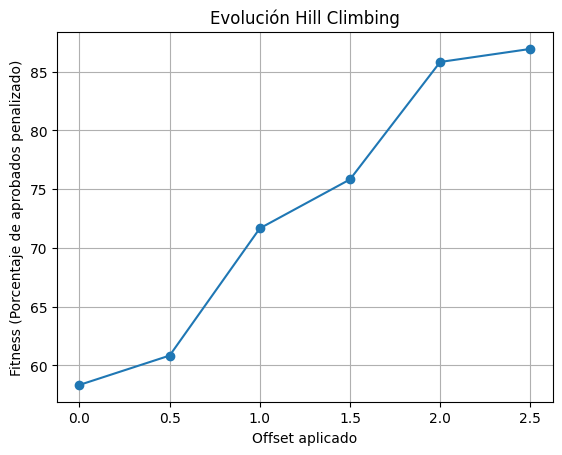

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Paso 1: Leer archivo Excel ---
df_full = pd.read_excel('dataset.xlsx', sheet_name='Grades')
df = df_full[['Parcial1', 'Parcial2', 'Parcial3']]

# --- Paso 2: Definir función fitness ---
def fitness(df, offset):
    df_offset = df + offset
    df_offset = df_offset.clip(0, 20)
    promedios = df_offset.mean(axis=1)

    #Porcentaje de aprobados
    porcentaje_aprobados = np.mean(promedios >= 11) * 100
    promedio_clase = promedios.mean()
    if promedio_clase > 14:
        penalizacion = (promedio_clase - 14) * 10
        return porcentaje_aprobados - penalizacion
    else:
        return porcentaje_aprobados


# --- Paso 3: Hill Climbing ---
def get_neighbors(current_offset, step=0.5, min_offset=-5, max_offset=5):
    neighbors = []
    if current_offset - step >= min_offset:
        neighbors.append(current_offset - step)
    if current_offset + step <= max_offset:
        neighbors.append(current_offset + step)
    return neighbors


def hill_climbing(df, max_iter=100, step=0.5):
    current_offset = 0
    current_score = fitness(df, current_offset)
    history = [(current_offset, current_score)]

    for _ in range(max_iter):
        neighbors = get_neighbors(current_offset, step)
        scores = [(offset, fitness(df, offset)) for offset in neighbors]

        # Obtener el mejor vecino
        best_neighbor = max(scores, key=lambda x: x[1])

        if best_neighbor[1] > current_score:
            current_offset, current_score = best_neighbor
            history.append((current_offset, current_score))
        else:
            break

    return current_offset, current_score, history

# Ejecutar algoritmo
offset_optimo, score_optimo, historial = hill_climbing(df)

print(f"Offset óptimo encontrado: {offset_optimo}")
print(f"Porcentaje de aprobados con offset óptimo: {score_optimo:.2f}%")

df_final = (df + offset_optimo).clip(0, 20)
promedios_final = df_final.mean(axis=1)
print(f"Promedio de la clase tras offset: {promedios_final.mean():.2f}")
print(f"Alumnos aprobados: {(promedios_final >= 11).sum()} de {len(promedios_final)}")

# --- Paso 4: Graficar evolución ---
offsets, scores = zip(*historial)
plt.plot(offsets, scores, marker='o')
plt.xlabel('Offset aplicado')
plt.ylabel('Fitness (Porcentaje de aprobados penalizado)')
plt.title('Evolución Hill Climbing')
plt.grid(True)
plt.show()
